# Phase 2 — Exploratory Data Analysis (EDA)
Stack Overflow Developer Survey 2025 — Salary deep-dive.

**Goals:**
- Understand salary distribution (skew, outliers, log-scale need)
- Salary by country, experience, role, and tech stack
- Correlation heatmap for numeric features
- Document 3–5 key findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## Load & Quick Filter

In [2]:
df = pd.read_csv('../data/results.txt', low_memory=False)

# Working subset: rows with a salary value
sal = df[df['ConvertedCompYearly'].notna()].copy()
print(f'Full dataset  : {len(df):,} rows')
print(f'With salary   : {len(sal):,} rows')

Full dataset  : 49,191 rows
With salary   : 23,947 rows


## 2.1 — Salary Distribution

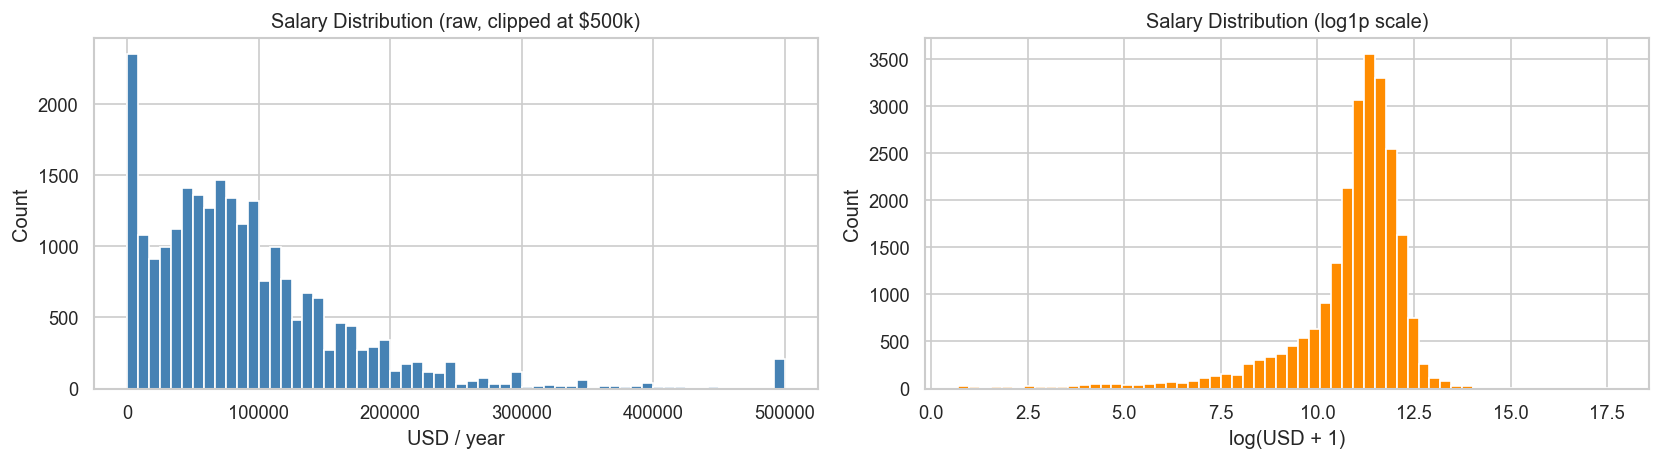

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw salary
axes[0].hist(sal['ConvertedCompYearly'].clip(upper=500_000), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Salary Distribution (raw, clipped at $500k)')
axes[0].set_xlabel('USD / year')
axes[0].set_ylabel('Count')

# Log-scale salary
log_sal = np.log1p(sal['ConvertedCompYearly'])
axes[1].hist(log_sal, bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Salary Distribution (log1p scale)')
axes[1].set_xlabel('log(USD + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../reports/salary_distribution.png', bbox_inches='tight')
plt.show()

print(sal['ConvertedCompYearly'].describe())

## 2.2 — Salary by Country (Top 15)

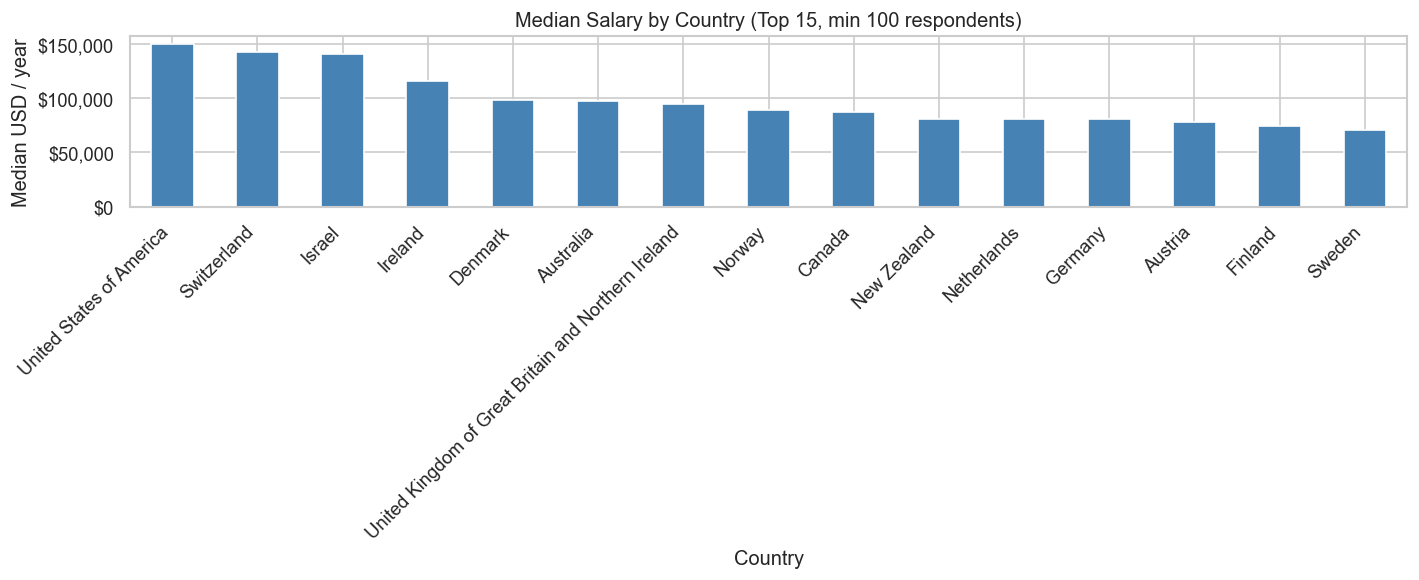

Country
United States of America                                $150,000
Switzerland                                             $142,592
Israel                                                  $141,188
Ireland                                                 $116,015
Denmark                                                  $98,678
Australia                                                $97,514
United Kingdom of Great Britain and Northern Ireland     $94,618
Norway                                                   $88,945
Canada                                                   $87,550
New Zealand                                              $81,318
Netherlands                                              $81,210
Germany                                                  $81,210
Austria                                                  $78,310
Finland                                                  $74,249
Sweden                                                   $70,440


In [4]:
# Keep countries with at least 100 salary respondents for stable medians
country_counts = sal['Country'].value_counts()
top_countries = country_counts[country_counts >= 100].index

country_sal = (
    sal[sal['Country'].isin(top_countries)]
    .groupby('Country')['ConvertedCompYearly']
    .median()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 5))
country_sal.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Median Salary by Country (Top 15, min 100 respondents)')
ax.set_xlabel('Country')
ax.set_ylabel('Median USD / year')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/salary_by_country.png', bbox_inches='tight')
plt.show()

print(country_sal.apply(lambda x: f'${x:,.0f}').to_string())

## 2.3 — Salary by Years of Experience (WorkExp)

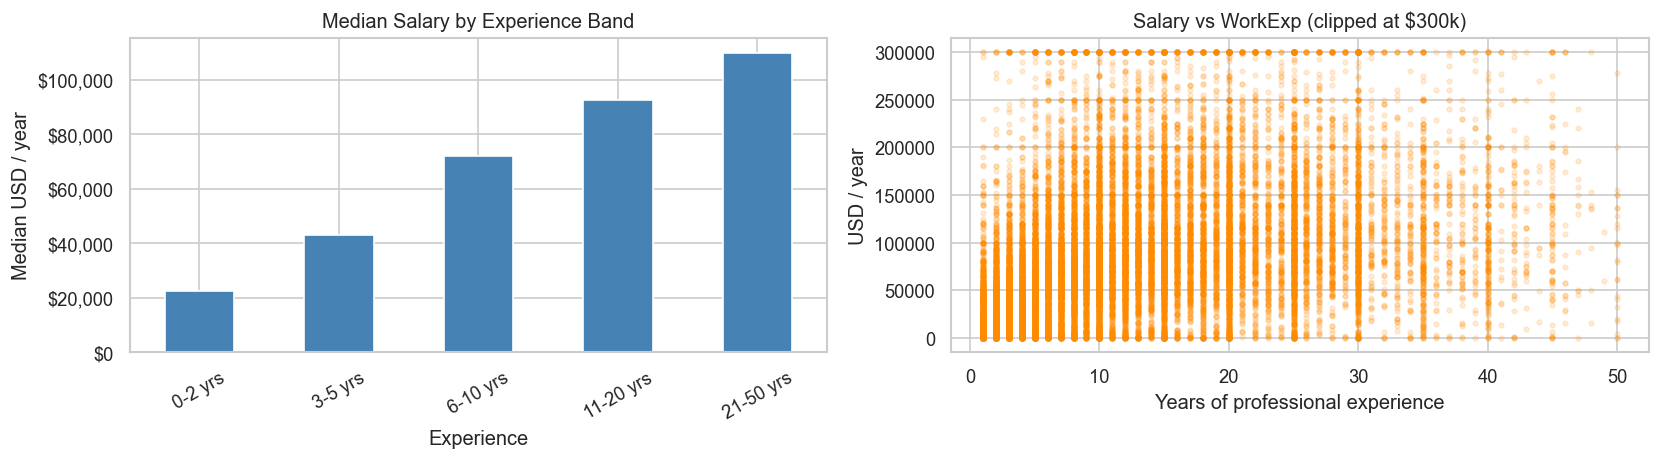

ExpBand
0-2 yrs       $22,667
3-5 yrs       $43,072
6-10 yrs      $72,000
11-20 yrs     $92,812
21-50 yrs    $110,000


In [5]:
# Remove bad WorkExp values (99, 100) and bucket into bands
exp = sal[sal['WorkExp'].between(0, 50)].copy()

bins   = [0, 2, 5, 10, 20, 50]
labels = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-20 yrs', '21-50 yrs']
exp['ExpBand'] = pd.cut(exp['WorkExp'], bins=bins, labels=labels, right=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Median salary per band
band_med = exp.groupby('ExpBand', observed=True)['ConvertedCompYearly'].median()
band_med.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Median Salary by Experience Band')
axes[0].set_xlabel('Experience')
axes[0].set_ylabel('Median USD / year')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=30)

# Scatter: raw WorkExp vs salary (clipped)
axes[1].scatter(
    exp['WorkExp'],
    exp['ConvertedCompYearly'].clip(upper=300_000),
    alpha=0.15, s=8, color='darkorange'
)
axes[1].set_title('Salary vs WorkExp (clipped at $300k)')
axes[1].set_xlabel('Years of professional experience')
axes[1].set_ylabel('USD / year')

plt.tight_layout()
plt.savefig('../reports/salary_by_experience.png', bbox_inches='tight')
plt.show()

print(band_med.apply(lambda x: f'${x:,.0f}').to_string())

## 2.4 — Salary by Role (DevType)

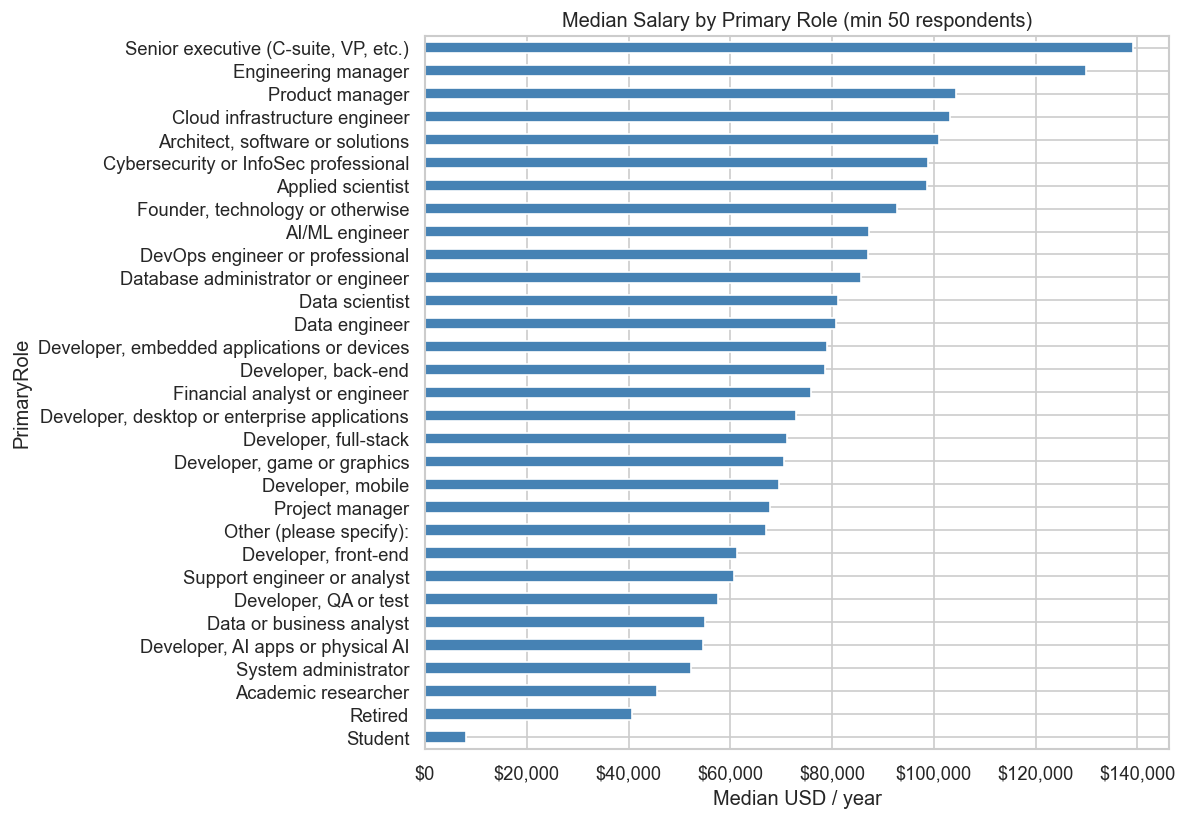

                                                 median  count
PrimaryRole                                                   
Senior executive (C-suite, VP, etc.)           $139,218    316
Engineering manager                            $130,000    717
Product manager                                $104,413    115
Cloud infrastructure engineer                  $103,112    266
Architect, software or solutions               $100,962   1626
Cybersecurity or InfoSec professional           $98,827    193
Applied scientist                               $98,612    162
Founder, technology or otherwise                $92,786    193
AI/ML engineer                                  $87,280    352
DevOps engineer or professional                 $87,011    697
Database administrator or engineer              $85,769     99
Data scientist                                  $81,210    345
Data engineer                                   $80,811    488
Developer, embedded applications or devices     $78,962

In [6]:
# DevType can be multi-select; take first listed role for simplicity
role_sal = sal.dropna(subset=['DevType']).copy()
role_sal['PrimaryRole'] = role_sal['DevType'].str.split(';').str[0].str.strip()

role_med = (
    role_sal.groupby('PrimaryRole')['ConvertedCompYearly']
    .agg(['median', 'count'])
    .query('count >= 50')
    .sort_values('median', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
role_med['median'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Median Salary by Primary Role (min 50 respondents)')
ax.set_xlabel('Median USD / year')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('../reports/salary_by_role.png', bbox_inches='tight')
plt.show()

print(role_med[['median', 'count']].sort_values('median', ascending=False)
      .assign(median=lambda d: d['median'].apply(lambda x: f'${x:,.0f}')).to_string())

## 2.5 — Salary by Tech Stack (Top Languages)

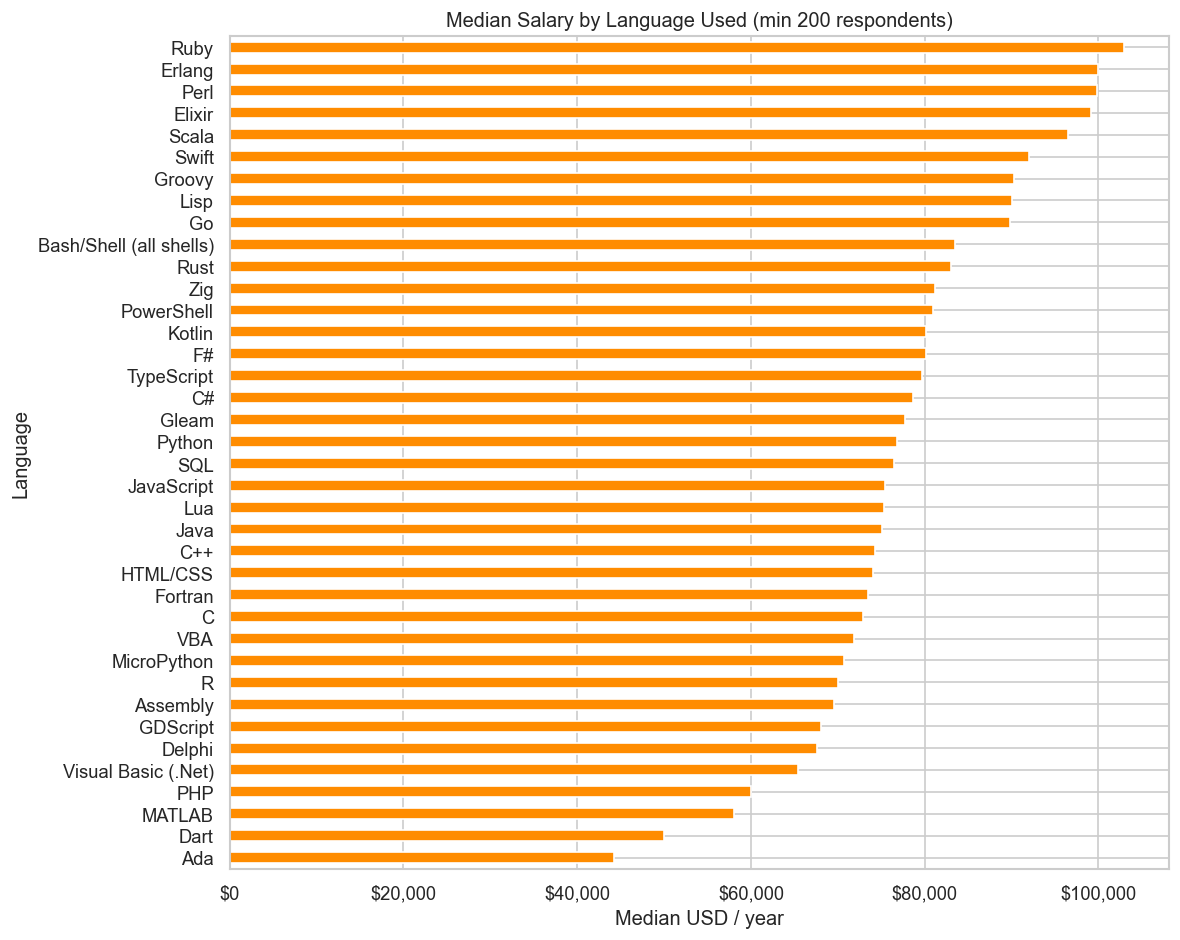

                           median  count
Language                                
Ruby                     $102,961   1550
Erlang                   $100,000    314
Perl                      $99,886    806
Elixir                    $99,194    615
Scala                     $96,524    600
Swift                     $92,000   1198
Groovy                    $90,233   1171
Lisp                      $90,000    459
Go                        $89,815   3783
Bash/Shell (all shells)   $83,531  11104
Rust                      $83,000   3117
Zig                       $81,210    399
PowerShell                $80,992   5334
Kotlin                    $80,152   2428
F#                        $80,127    262
TypeScript                $79,648  10336
C#                        $78,616   6397
Gleam                     $77,730    209
Python                    $76,828  12730
SQL                       $76,518  13546
JavaScript                $75,410  14873
Lua                       $75,320   1857
Java            

In [7]:
# Explode multi-select language column, then compute median salary per language
lang = sal.dropna(subset=['LanguageHaveWorkedWith']).copy()
lang = lang.assign(
    Language=lang['LanguageHaveWorkedWith'].str.split(';')
).explode('Language')
lang['Language'] = lang['Language'].str.strip()

lang_sal = (
    lang.groupby('Language')['ConvertedCompYearly']
    .agg(['median', 'count'])
    .query('count >= 200')
    .sort_values('median', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
lang_sal['median'].plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Median Salary by Language Used (min 200 respondents)')
ax.set_xlabel('Median USD / year')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('../reports/salary_by_language.png', bbox_inches='tight')
plt.show()

print(lang_sal.sort_values('median', ascending=False)
      .assign(median=lambda d: d['median'].apply(lambda x: f'${x:,.0f}')).to_string())

## 2.6 — Correlation Heatmap (Numeric Features)

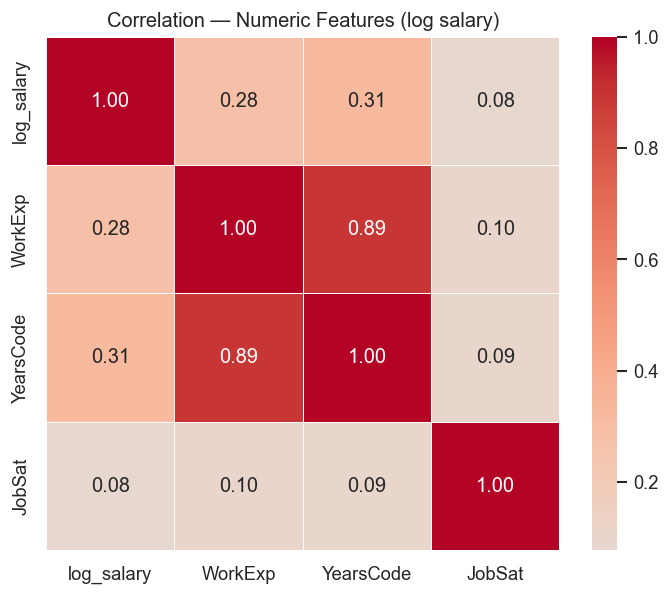

            log_salary   WorkExp  YearsCode    JobSat
log_salary    1.000000  0.282972   0.312232  0.077854
WorkExp       0.282972  1.000000   0.889938  0.099845
YearsCode     0.312232  0.889938   1.000000  0.089768
JobSat        0.077854  0.099845   0.089768  1.000000


In [8]:
num_cols = ['ConvertedCompYearly', 'WorkExp', 'YearsCode', 'JobSat']
num_df = sal[num_cols].dropna()

# Log-transform salary for correlation
num_df = num_df.copy()
num_df['log_salary'] = np.log1p(num_df['ConvertedCompYearly'])

corr = num_df[['log_salary', 'WorkExp', 'YearsCode', 'JobSat']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Correlation — Numeric Features (log salary)')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', bbox_inches='tight')
plt.show()

print(corr.to_string())

## 2.7 — Key EDA Findings

1. **Salary is heavily right-skewed** — raw mean ($101,762) is pulled far above median ($75,320) by extreme outliers up to $50M. Log-transform is confirmed necessary for modelling.

2. **Location dominates salary** — USA median ($150,000) is ~2–4× higher than Eastern Europe or South Asia. Switzerland ($142,592) and Israel ($141,188) also rank near the top. Country must be a top feature in the model.

3. **Experience matters but plateaus** — median salary rises steeply from 0–2 yrs ($22,667) through 6–10 yrs ($72,000) and 11–20 yrs ($92,812), then levels off at 21–50 yrs ($110,000). Diminishing returns after ~10 years.

4. **Role gap is significant** — Senior Executive ($139,218) and Engineering Manager ($130,000) earn ~6× more than entry-level developers. Cloud, Architect, and AI/ML roles ($87k–$103k) sit in the middle tier. Primary role is a strong predictor.

5. **Language premium exists but is confounded** — Ruby ($102,961), Erlang ($100,000), and Scala ($96,524) rank highest; Go ($89,815) and Rust ($83,000) also above average. However, this is partly confounded with country and seniority — needs SHAP analysis to isolate true language effect.

6. **Experience and total years coding are nearly collinear** — correlation of 0.89 between WorkExp and YearsCode. Only one should be used as a feature to avoid multicollinearity. WorkExp (professional years) is preferred. Log salary correlates moderately with both (r ≈ 0.28–0.31). Job satisfaction has almost no linear relationship with salary (r = 0.08).